In [11]:
import sys
from pathlib import Path

from OMPython import ModelicaSystem

repo_root = Path.cwd().parent.parent.parent.parent
sys.path.insert(0, str(repo_root))
import docs.plot_setup as plot_setup
plt = plot_setup.set_professional_style()

In [12]:
pkg_path = Path.cwd() / 'ControlledPendulum/package.mo'
model_name = 'ControlledPendulum.Demo_DrivenWithWallDiscrete'

def get_contact_times(contact_signal, time_signal):
    return [time_signal[i] for i, val in enumerate(contact_signal) if val]

reset_values = ('false', 'true')
solution_names = ('time', 'pid.I_out', 'reference.q_ref', 'pendulum.q', 'pendulum.contact')
results = {reset_value: {} for reset_value in reset_values}

startTime = 0.0
stopTime  = 10.0
stepSize  = 0.001

for pid_reset_value in reset_values:
    model = ModelicaSystem(str(pkg_path), model_name)
    model.setParameters(f'useReset={pid_reset_value}')
    model.buildModel()
    print(model.getParameters('useReset'))  # To verify parameter setting
    model.setSimulationOptions([f'startTime={startTime}', f'stopTime={stopTime}', f'stepSize={stepSize}'])
    model.simulate()
    res = {name: model.getSolutions(name).flatten() for name in solution_names}
    results[pid_reset_value] = res
    results[pid_reset_value]['contact_times'] = get_contact_times(res['pendulum.contact'], res['time'])


Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package Modelica 4.0.0 due to usage.


['false']
LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.
LOG_SUCCESS       | info    | The simulation finished successfully.

Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package Modelica 4.0.0 due to usage.


['true']
LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.
LOG_SUCCESS       | info    | The simulation finished successfully.


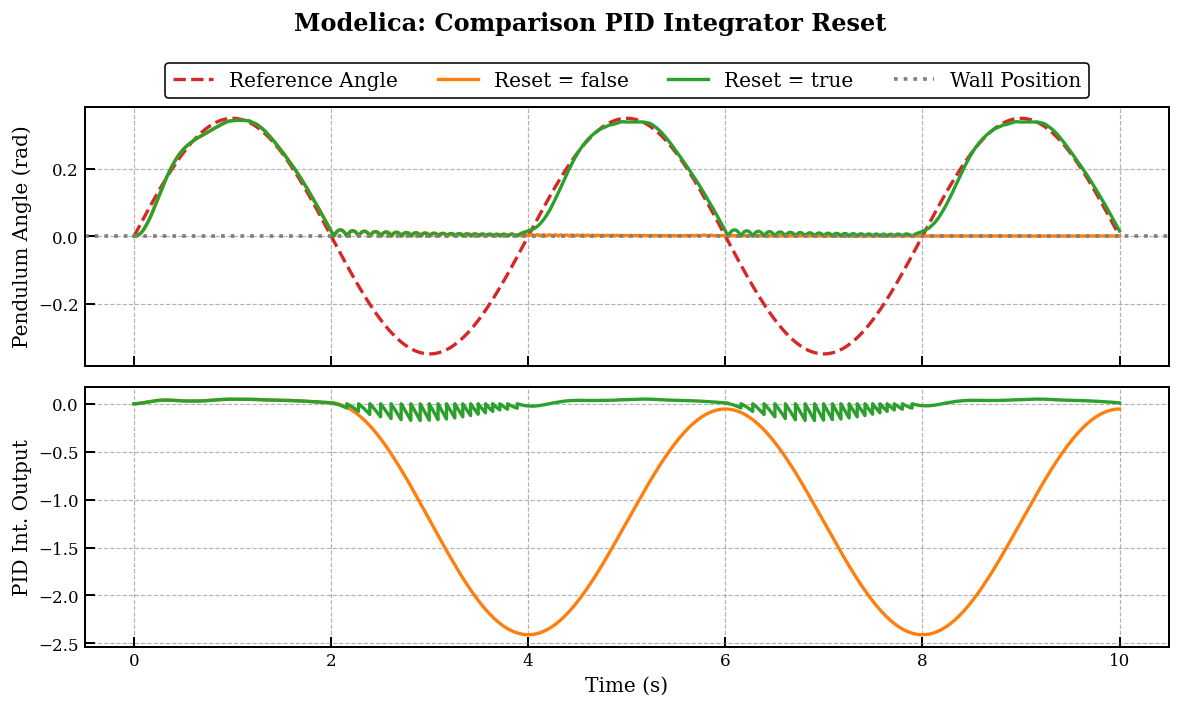

In [14]:
style_reset_true = {'color': 'tab:green', 'linestyle': '-', 'linewidth': 2, 'label': 'Reset = true'}
style_reset_false = {'color': 'tab:orange', 'linestyle': '-', 'linewidth': 2, 'label': 'Reset = false'}

fig, axs = plt.subplots(ncols=1, nrows=2, sharex=True)
fig.set_size_inches(10,6)

fig.suptitle(f'Modelica: Comparison PID Integrator Reset', fontweight='bold')

axs[0].plot(results['false']['time'], results['false']['reference.q_ref'], label='Reference Angle', color='tab:red', linestyle='--', linewidth=2)
axs[0].plot(results['false']['time'], results['false']['pendulum.q'], **style_reset_false)
axs[0].plot(results['true']['time'], results['true']['pendulum.q'], **style_reset_true)
axs[0].axhline(y=0, color='tab:gray', linestyle=':', label='Wall Position')
axs[0].set_ylabel('Pendulum Angle (rad)')
axs[0].grid()

axs[0].legend(loc='center', bbox_to_anchor=(0.5, 1.1), ncols=4)

axs[1].plot(results['false']['time'], results['false']['pid.I_out'], **style_reset_false)
axs[1].plot(results['true']['time'], results['true']['pid.I_out'], **style_reset_true)
axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('PID Int. Output')
axs[1].grid()
plt.tight_layout()
plt.savefig('../figures/Hybrid/Modelica_PID_Integrator_Reset_Comparison.svg')